# Ma'al Project — Investor Model Training

## Team Members
- Abdulaziz Alsharif
- Anas Al-Zahrani
- Mohammed
- Majid

## Problem Description
This notebook builds a regression model to predict the investment_score for startups.
The goal is to help investors evaluate startup opportunities using funding, traction, revenue, market growth, and company profile features.
The model compares a simple Linear Regression baseline with a Random Forest Regressor to select the best final model.

In [31]:
DROP_LEAKAGE = True
# ==============================
# Investor Dataset - Preprocessing + Visualization (CORRECTED)
# Ma'al Project
# Target: investment_score | Task: Regression
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [32]:
# ==============================
# 1) Load Dataset
# ==============================

investor_path = "/content/investor_dataset.csv"
df = pd.read_csv(investor_path)

print("Investor Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Investor Dataset Shape: (5000, 20)

Columns:
['sector', 'city', 'founded_year', 'startup_age_years', 'funding_stage', 'total_funding_sar', 'num_funding_rounds', 'num_investors', 'num_founders', 'speed_to_first_round_months', 'last_round_type', 'sama_sandbox', 'rega_sandbox', 'ntdp_participation', 'market_growth_index', 'traction_score', 'monthly_revenue_sar', 'risk_category', 'survived_3_years', 'investment_score']


In [33]:
# ==============================
# 2) Expected Columns Check
# ==============================

expected_columns = [
    "sector",
    "city",
    "founded_year",
    "startup_age_years",
    "funding_stage",
    "total_funding_sar",
    "num_funding_rounds",
    "num_investors",
    "num_founders",
    "speed_to_first_round_months",
    "last_round_type",
    "sama_sandbox",
    "rega_sandbox",
    "ntdp_participation",
    "market_growth_index",
    "traction_score",
    "monthly_revenue_sar",
    "risk_category",
    "survived_3_years",
    "investment_score"
]

actual_columns = df.columns.tolist()

missing_columns = [col for col in expected_columns if col not in actual_columns]
extra_columns = [col for col in actual_columns if col not in expected_columns]

print("\n==============================")
print("Investor Feature Check")
print("==============================")

if len(missing_columns) == 0 and len(extra_columns) == 0:
    print("✅ الأعمدة مطابقة للمتطلبات")
else:
    print("❌ فيه اختلاف في الأعمدة")

print("Missing Columns:", missing_columns)
print("Extra Columns:", extra_columns)


Investor Feature Check
✅ الأعمدة مطابقة للمتطلبات
Missing Columns: []
Extra Columns: []


In [34]:
# ==============================
# 3) Basic Data Quality Check
# ==============================

print("\n==============================")
print("Data Quality Report")
print("==============================")

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicated Rows:")
print(df.duplicated().sum())

print("\nNumerical Summary:")
print(df.describe())


Data Quality Report

Data Types:
sector                          object
city                            object
founded_year                     int64
startup_age_years                int64
funding_stage                   object
total_funding_sar                int64
num_funding_rounds               int64
num_investors                    int64
num_founders                     int64
speed_to_first_round_months      int64
last_round_type                 object
sama_sandbox                     int64
rega_sandbox                     int64
ntdp_participation               int64
market_growth_index            float64
traction_score                 float64
monthly_revenue_sar              int64
risk_category                   object
survived_3_years                 int64
investment_score               float64
dtype: object

Missing Values:
sector                         0
city                           0
founded_year                   0
startup_age_years              0
funding_stage          

In [35]:
# ==============================
# 4) Binary Columns Check
# ==============================

binary_columns = [
    "sama_sandbox",
    "rega_sandbox",
    "ntdp_participation",
    "survived_3_years"
]

print("\n==============================")
print("Binary Columns Check")
print("==============================")

for col in binary_columns:
    values = sorted(df[col].dropna().unique())
    if set(values).issubset({0, 1}):
        print(f"✅ {col} صحيح: {values}")
    else:
        print(f"❌ {col} فيه قيم غير صحيحة: {values}")




Binary Columns Check
✅ sama_sandbox صحيح: [np.int64(0), np.int64(1)]
✅ rega_sandbox صحيح: [np.int64(0), np.int64(1)]
✅ ntdp_participation صحيح: [np.int64(0), np.int64(1)]
✅ survived_3_years صحيح: [np.int64(0), np.int64(1)]


In [36]:
# ==============================
# 5) Range Checks
# ==============================

range_checks = {
    "investment_score": (0, 100),
    "market_growth_index": (0, 1),
    "traction_score": (0, 100)
}

print("\n==============================")
print("Range Checks")
print("==============================")

for col, (min_value, max_value) in range_checks.items():
    invalid_rows = df[(df[col] < min_value) | (df[col] > max_value)]
    if invalid_rows.empty:
        print(f"✅ {col} داخل النطاق الصحيح من {min_value} إلى {max_value}")
    else:
        print(f"❌ {col} فيه قيم خارج النطاق")
        print(invalid_rows[[col]].head())


Range Checks
✅ investment_score داخل النطاق الصحيح من 0 إلى 100
✅ market_growth_index داخل النطاق الصحيح من 0 إلى 1
✅ traction_score داخل النطاق الصحيح من 0 إلى 100


In [37]:
# ==============================
# 6) Redundancy + Leakage Check (NEW - IMPORTANT)
#    Drop columns that leak the target or duplicate other columns:
#      - last_round_type : identical to funding_stage  (redundant)
#      - founded_year    : duplicate info of startup_age_years (redundant)
#      - survived_3_years: derived from same survival prob as target (LEAKAGE)
#      - risk_category   : derived from same survival prob as target (LEAKAGE)
# ==============================

print("\n==============================")
print("Redundancy & Leakage Check")
print("==============================")

# Redundancy
same_round = (df["last_round_type"] == df["funding_stage"]).all()
print(f"last_round_type == funding_stage : {same_round}")

ref_year = int((df["founded_year"] + df["startup_age_years"]).mode()[0])
same_age = (df["startup_age_years"] == (ref_year - df["founded_year"])).all()
print(f"startup_age_years = {ref_year} - founded_year : {same_age}")

# Leakage (correlation with target)
leak_survived = df["survived_3_years"].corr(df["investment_score"])
print(f"corr(survived_3_years, investment_score) : {leak_survived:.3f}  -> تسريب")
print("risk_category mean investment_score by group (تسريب):")
print(df.groupby("risk_category")["investment_score"].mean().round(1).to_string())


Redundancy & Leakage Check
last_round_type == funding_stage : True
startup_age_years = 2024 - founded_year : True
corr(survived_3_years, investment_score) : 0.371  -> تسريب
risk_category mean investment_score by group (تسريب):
risk_category
High      42.4
Low       76.5
Medium    55.0


In [38]:
# ==============================
# 7) Cleaning
# ==============================

df_clean = df.copy()

# Remove duplicated rows
df_clean = df_clean.drop_duplicates()

# Clean text columns
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Fill missing values
numerical_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nCleaned Investor Dataset Shape:", df_clean.shape)



Cleaned Investor Dataset Shape: (5000, 20)


In [39]:
# ==============================
# 8) Outlier Detection + Handling - IQR (FIXED)
#    Cap outliers instead of only printing. Target excluded.
# ==============================

target = "investment_score"

print("\n==============================")
print("Outlier Report (before capping)")
print("==============================")

cols_to_cap = [c for c in numerical_cols if c != target]

for col in cols_to_cap:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

print("\n✅ Outliers capped to IQR bounds")


Outlier Report (before capping)
founded_year: 0 outliers
startup_age_years: 0 outliers
total_funding_sar: 810 outliers
num_funding_rounds: 53 outliers
num_investors: 457 outliers
num_founders: 0 outliers
speed_to_first_round_months: 29 outliers
sama_sandbox: 572 outliers
rega_sandbox: 495 outliers
ntdp_participation: 0 outliers
market_growth_index: 0 outliers
traction_score: 0 outliers
monthly_revenue_sar: 1033 outliers
survived_3_years: 0 outliers

✅ Outliers capped to IQR bounds


In [40]:

# ==============================
# 9) Drop Redundant + Leaking Columns (NEW - IMPORTANT)
# ==============================

drop_cols = []

# Redundant
if (df_clean["last_round_type"] == df_clean["funding_stage"]).all():
    drop_cols.append("last_round_type")
if (df_clean["startup_age_years"] == (ref_year - df_clean["founded_year"])).all():
    drop_cols.append("founded_year")

# Leakage — these encode the target and must NOT be model inputs
if DROP_LEAKAGE:
    drop_cols += ["survived_3_years", "risk_category"]
    print("⚠️  Leakage columns dropped (DROP_LEAKAGE=True)")
else:
    print("ℹ️  Leakage columns kept (DROP_LEAKAGE=False)")

df_clean = df_clean.drop(columns=drop_cols)
print("\nDropped columns (redundant + leakage):", drop_cols)
print("Investor Dataset Shape after drop:", df_clean.shape)


⚠️  Leakage columns dropped (DROP_LEAKAGE=True)

Dropped columns (redundant + leakage): ['last_round_type', 'founded_year', 'survived_3_years', 'risk_category']
Investor Dataset Shape after drop: (5000, 16)


In [41]:
# ==============================
# FEATURE ENGINEERING
# ==============================

df_clean["funding_per_round"] = df_clean["total_funding_sar"] / df_clean["num_funding_rounds"].replace(0, np.nan)
df_clean["funding_per_round"] = df_clean["funding_per_round"].fillna(0)

df_clean["investment_per_founder"] = df_clean["total_funding_sar"] / df_clean["num_founders"].replace(0, np.nan)
df_clean["investment_per_founder"] = df_clean["investment_per_founder"].fillna(0)

df_clean["regulatory_support"] = df_clean["sama_sandbox"] + df_clean["rega_sandbox"] + df_clean["ntdp_participation"]

df_clean["revenue_funding_ratio"] = df_clean["monthly_revenue_sar"] / df_clean["total_funding_sar"].replace(0, np.nan)
df_clean["revenue_funding_ratio"] = df_clean["revenue_funding_ratio"].fillna(0)

print("✅ Feature engineering done")
print(df_clean[["funding_per_round", "investment_per_founder", "regulatory_support", "revenue_funding_ratio"]].describe())


✅ Feature engineering done
       funding_per_round  investment_per_founder  regulatory_support  \
count        5000.000000             5000.000000          5000.00000   
mean         2784.668218             5105.429515             0.35180   
std          3003.039259             7572.350307             0.47758   
min            50.000000               25.250000             0.00000   
25%           369.750000              267.750000             0.00000   
50%          1389.750000             1263.000000             0.00000   
75%          4901.050000             7283.250000             1.00000   
max         11846.208333            35538.625000             1.00000   

       revenue_funding_ratio  
count            5000.000000  
mean               30.528585  
std                21.098630  
min                 0.020000  
25%                15.726233  
50%                29.265741  
75%                36.554644  
max               159.731478  


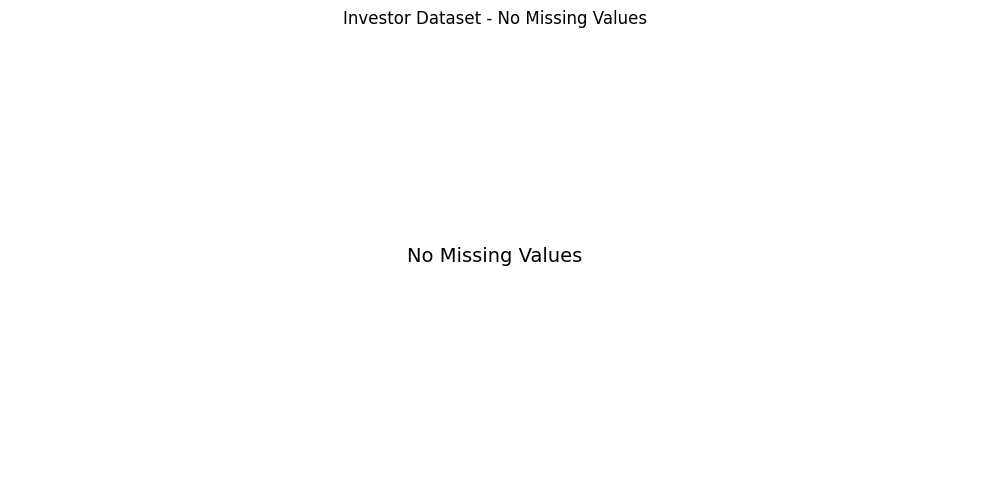

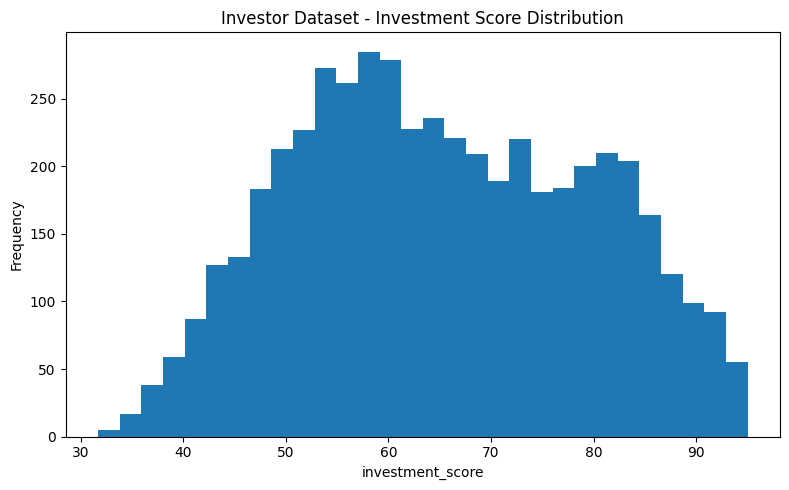

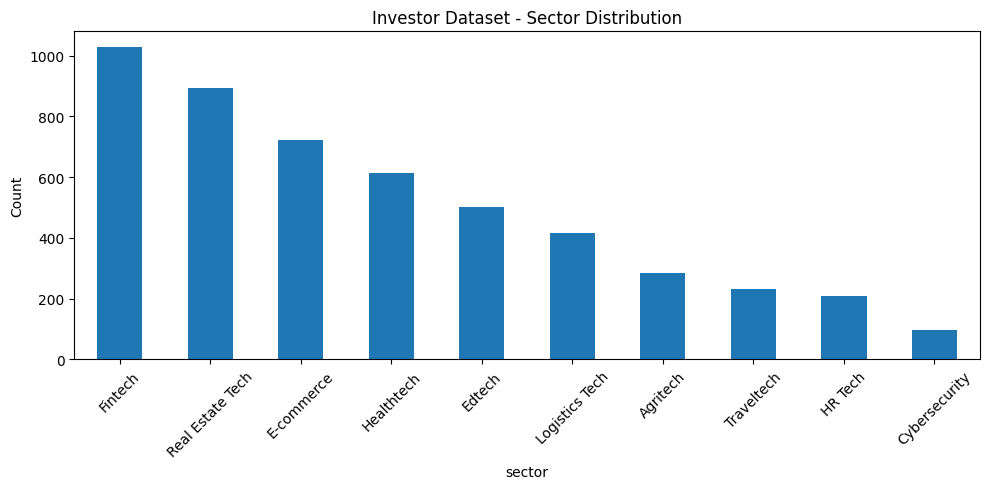

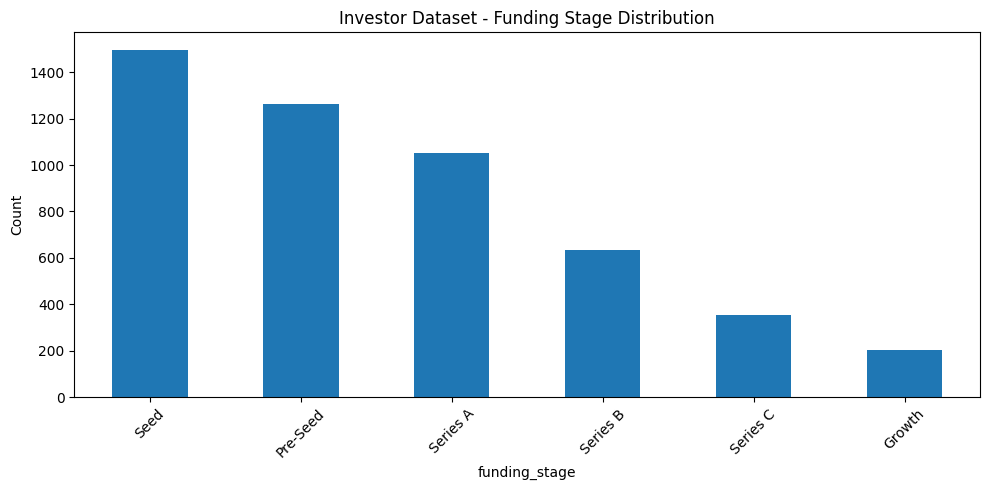

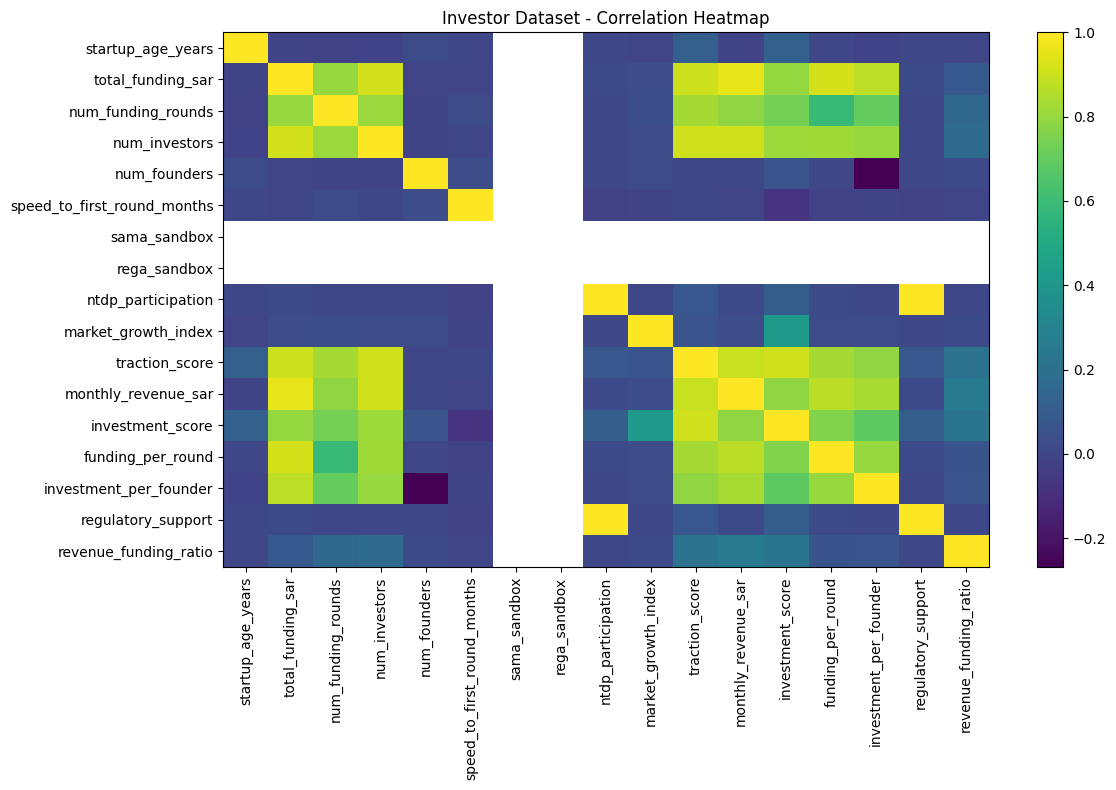

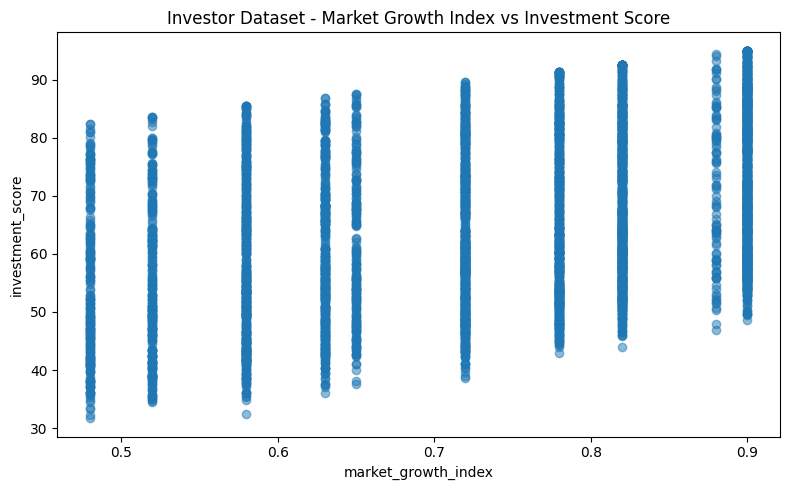

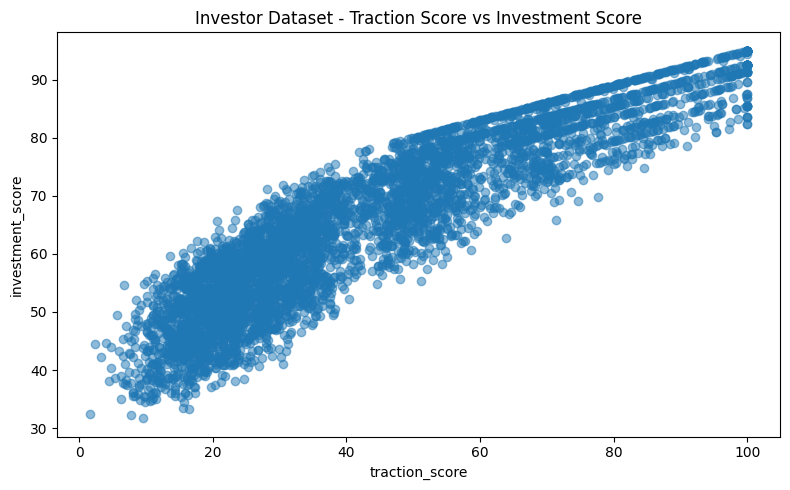

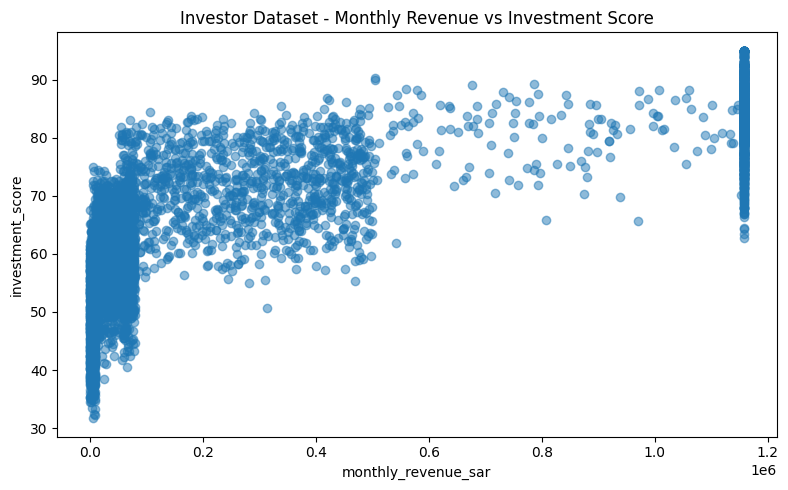

In [42]:
# ==============================
# 10) Visualization
# ==============================

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
if len(missing) == 0:
    plt.title("Investor Dataset - No Missing Values")
    plt.text(0.5, 0.5, "No Missing Values", ha="center", va="center", fontsize=14)
    plt.axis("off")
else:
    missing.plot(kind="bar")
    plt.title("Investor Dataset - Missing Values")
    plt.xlabel("Columns")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Target distribution
plt.figure(figsize=(8, 5))
plt.hist(df_clean["investment_score"], bins=30)
plt.title("Investor Dataset - Investment Score Distribution")
plt.xlabel("investment_score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Sector distribution
plt.figure(figsize=(10, 5))
df_clean["sector"].value_counts().plot(kind="bar")
plt.title("Investor Dataset - Sector Distribution")
plt.xlabel("sector")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Funding stage distribution
plt.figure(figsize=(10, 5))
df_clean["funding_stage"].value_counts().plot(kind="bar")
plt.title("Investor Dataset - Funding Stage Distribution")
plt.xlabel("funding_stage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap
numeric_df = df_clean.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Investor Dataset - Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter: market growth vs investment score
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["market_growth_index"], df_clean["investment_score"], alpha=0.5)
plt.title("Investor Dataset - Market Growth Index vs Investment Score")
plt.xlabel("market_growth_index")
plt.ylabel("investment_score")
plt.tight_layout()
plt.show()

# Scatter: traction score vs investment score
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["traction_score"], df_clean["investment_score"], alpha=0.5)
plt.title("Investor Dataset - Traction Score vs Investment Score")
plt.xlabel("traction_score")
plt.ylabel("investment_score")
plt.tight_layout()
plt.show()

# Scatter: monthly revenue vs investment score
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["monthly_revenue_sar"], df_clean["investment_score"], alpha=0.5)
plt.title("Investor Dataset - Monthly Revenue vs Investment Score")
plt.xlabel("monthly_revenue_sar")
plt.ylabel("investment_score")
plt.tight_layout()
plt.show()









In [43]:
# ==============================
# 11) Prepare X and y
# ==============================

X = df_clean.drop(columns=["investment_score"])
y = df_clean["investment_score"]

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)
print("Feature columns:", X.columns.tolist())


X Shape: (5000, 19)
y Shape: (5000,)
Feature columns: ['sector', 'city', 'startup_age_years', 'funding_stage', 'total_funding_sar', 'num_funding_rounds', 'num_investors', 'num_founders', 'speed_to_first_round_months', 'sama_sandbox', 'rega_sandbox', 'ntdp_participation', 'market_growth_index', 'traction_score', 'monthly_revenue_sar', 'funding_per_round', 'investment_per_founder', 'regulatory_support', 'revenue_funding_ratio']


In [44]:
# ==============================
# 12) Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)



X_train: (4000, 19)
X_test: (1000, 19)
y_train: (4000,)
y_test: (1000,)


In [45]:
# ==============================
# 13) Preprocessing Pipeline
#     No StandardScaler for Random Forest (tree-based, scale-invariant).
# ==============================

categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n==============================")
print("Investor Preprocessing Done")
print("==============================")
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)
print("Processed X_train Shape:", X_train_processed.shape)
print("Processed X_test Shape:", X_test_processed.shape)

print("\n✅ Investor Dataset جاهز للتدريب")
print("Target: investment_score")
print("Task Type: Regression")


Investor Preprocessing Done
Numerical Features: ['startup_age_years', 'total_funding_sar', 'num_funding_rounds', 'num_investors', 'num_founders', 'speed_to_first_round_months', 'sama_sandbox', 'rega_sandbox', 'ntdp_participation', 'market_growth_index', 'traction_score', 'monthly_revenue_sar', 'funding_per_round', 'investment_per_founder', 'regulatory_support', 'revenue_funding_ratio']
Categorical Features: ['sector', 'city', 'funding_stage']
Processed X_train Shape: (4000, 40)
Processed X_test Shape: (1000, 40)

✅ Investor Dataset جاهز للتدريب
Target: investment_score
Task Type: Regression


In [46]:
# learning curve helper function
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8,5))

    plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation Score")

    plt.fill_between(
        train_sizes,
        train_mean-train_std,
        train_mean+train_std,
        alpha=0.2
    )

    plt.fill_between(
        train_sizes,
        val_mean-val_std,
        val_mean+val_std,
        alpha=0.2
    )

    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("R² Score")
    plt.grid(True)
    plt.legend()
    plt.show()

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# ==============================
# 14) LINEAR REGRESSION BASELINE MODEL
# ==============================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

linear_pred = linear_model.predict(X_test_processed)

linear_r2 = r2_score(y_test, linear_pred)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

cv_r2 = cross_val_score(
    linear_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2"
).mean()

print("\n==============================")
print("Linear Regression Baseline Results")
print("==============================")
print(f"R² Score : {linear_r2:.4f}")
print(f"MAE      : {linear_mae:.2f} pts")
print(f"RMSE     : {linear_rmse:.2f} pts")
print(f"CV R²    : {cv_r2:.2f}")


Linear Regression Baseline Results
R² Score : 0.9879
MAE      : 1.26 pts
RMSE     : 1.57 pts
CV R²    : 0.99


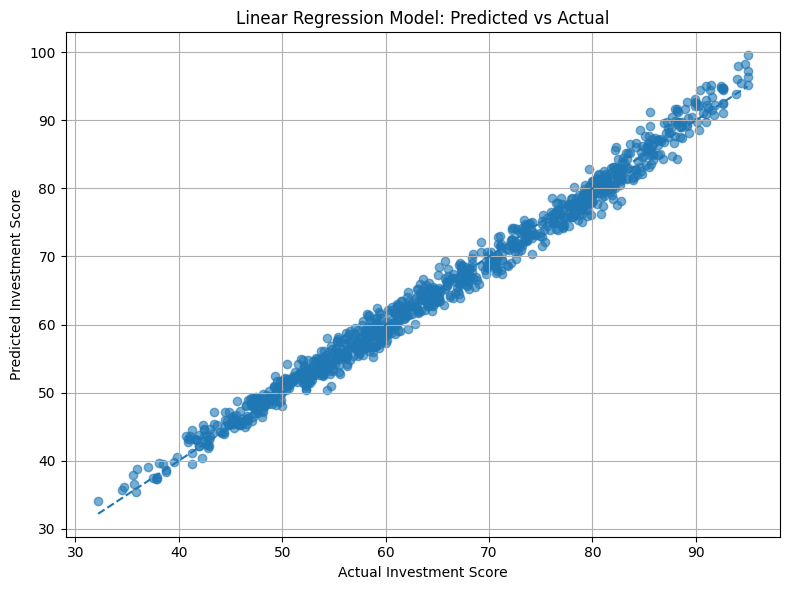

In [48]:
# ==============================
# PREDICTED VS ACTUAL SCATTER PLOT
# ==============================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Investment Score")
plt.ylabel("Predicted Investment Score")
plt.title("Linear Regression Model: Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

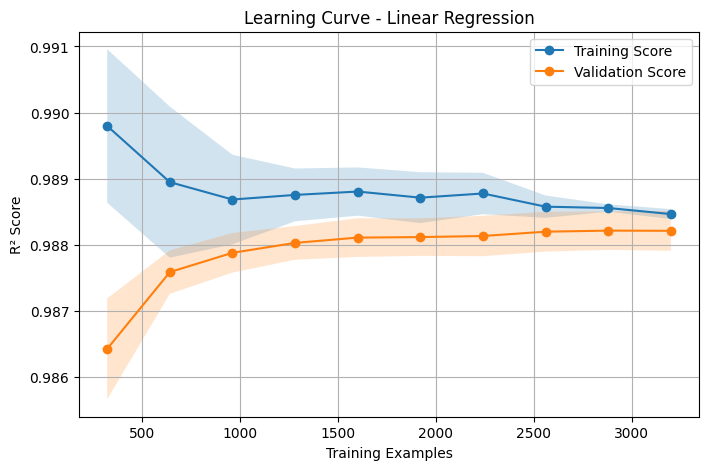

In [49]:
# linear regression learning curve
plot_learning_curve(
    linear_model,
    X_train_processed,
    y_train,
    "Learning Curve - Linear Regression"
)

In [50]:
# ============================================
#  Decision Tree Model training and evaluation
# ============================================

from sklearn.tree import DecisionTreeRegressor

tree_model= DecisionTreeRegressor( max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)

tree_model.fit(X_train_processed, y_train)

tree_pred= tree_model.predict(X_test_processed)

tree_r2= r2_score(y_test, tree_pred)
tree_mae= mean_absolute_error(y_test,tree_pred)
tree_rmse= np.sqrt(mean_squared_error(y_test, tree_pred))

cv_r2 = cross_val_score(
    tree_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2"
).mean()

print("\n==============================")
print("Decision Tree Results")
print("==============================")
print(f"R² Score : {tree_r2:.4f}")
print(f"MAE      : {tree_mae:.2f} pts")
print(f"RMSE     : {tree_rmse:.2f} pts")
print(f"CV R²    : {cv_r2:.2f}")



Decision Tree Results
R² Score : 0.9751
MAE      : 1.64 pts
RMSE     : 2.25 pts
CV R²    : 0.98


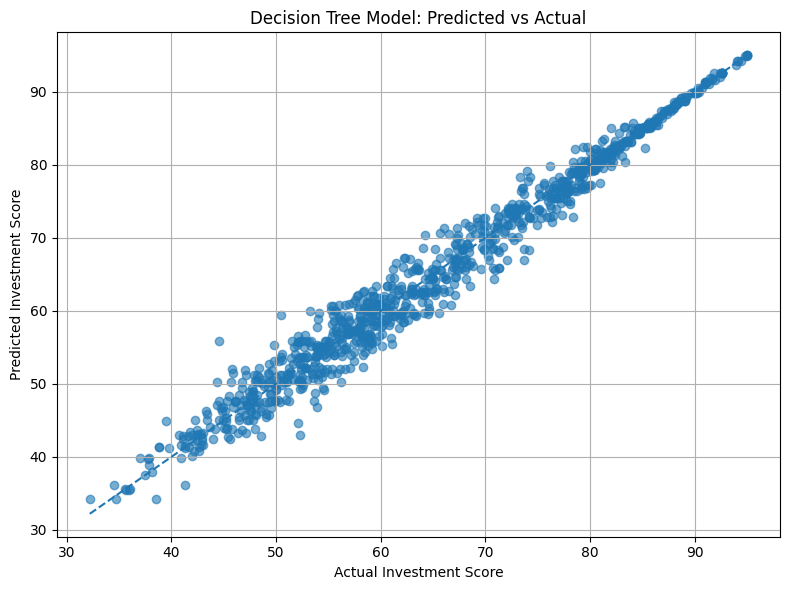

In [51]:
# ==============================
# PREDICTED VS ACTUAL SCATTER PLOT
# ==============================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, tree_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Investment Score")
plt.ylabel("Predicted Investment Score")
plt.title("Decision Tree Model: Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

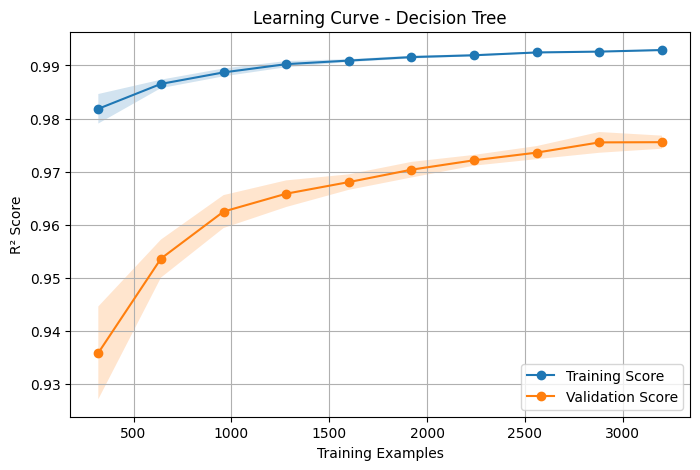

In [52]:
# Decision tree learning curve.

plot_learning_curve(
    tree_model,
    X_train_processed,
    y_train,
    "Learning Curve - Decision Tree"
)

In [53]:
# ==============================
# MODEL TRAINING - Random Forest
# ==============================

model = RandomForestRegressor(
    n_estimators= 500,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=4,
    random_state=42
)

model.fit(X_train_processed, y_train)


RandomForestRegressor(max_depth=12, min_samples_leaf=4, min_samples_split=4,
                      n_estimators=500, random_state=42)

In [54]:
# ==============================
# EVALUATION
# ==============================

y_pred = model.predict(X_test_processed)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
cv_r2 = cross_val_score(model, X_train_processed, y_train, cv=5, scoring="r2").mean()

print("==============================")
print("Investor Random Forest Final Model Evaluation")
print("==============================")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f} pts")
print(f"RMSE     : {rmse:.2f} pts")
print(f"CV R²    : {cv_r2:.2f}")

Investor Random Forest Final Model Evaluation
R² Score : 0.9874
MAE      : 1.20 pts
RMSE     : 1.60 pts
CV R²    : 0.99


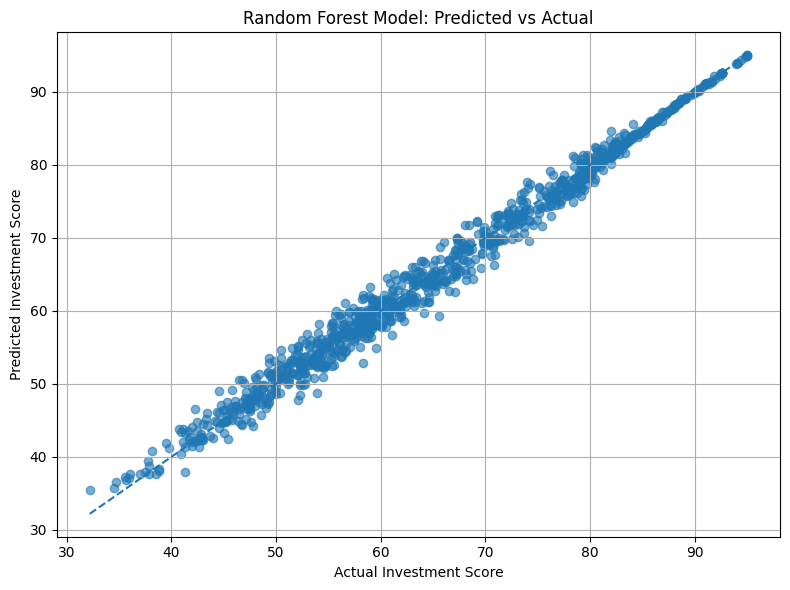

In [55]:
# ==============================
# PREDICTED VS ACTUAL SCATTER PLOT
# ==============================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Investment Score")
plt.ylabel("Predicted Investment Score")
plt.title("Random Forest Model: Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

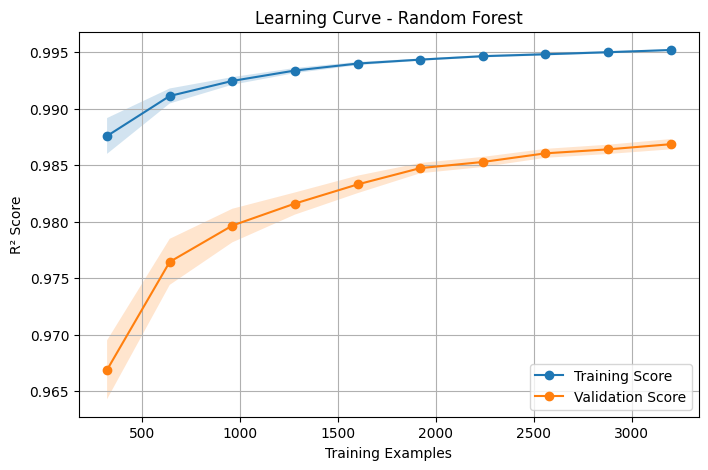

In [56]:
# random forest learning curve.

plot_learning_curve(
    model,
    X_train_processed,
    y_train,
    "Learning Curve - Random Forest"
)

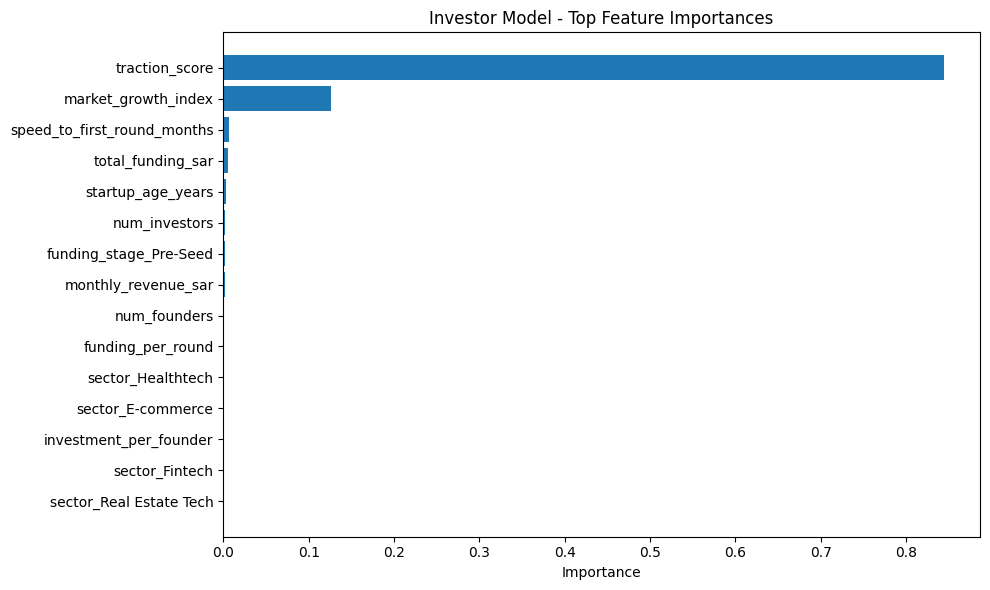

,Feature,Importance
10,traction_score,0.844302
9,market_growth_index,0.126142
5,speed_to_first_round_months,0.006852
1,total_funding_sar,0.004993
0,startup_age_years,0.003272
3,num_investors,0.001920
35,funding_stage_Pre-Seed,0.001640
11,monthly_revenue_sar,0.001510
4,num_founders,0.001264
12,funding_per_round,0.001123


In [57]:
# ==============================
# FEATURE IMPORTANCE PLOT
# ==============================

feature_names = (
    numerical_features
    + list(preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_features))
)
importances = model.feature_importances_
top_n = 15
indices = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in indices][::-1], importances[indices][::-1])
plt.title("Investor Model - Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

In [58]:
# ==============================
#  Model Comparison
# ==============================

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression","Decision Tree", "Random Forest"],
    "R² Score": [linear_r2, tree_r2,r2],
    "MAE": [linear_mae, tree_mae,mae],
    "RMSE": [linear_rmse, tree_rmse,rmse]
})

print("\n==============================")
print("Model Comparison")
print("==============================")
print(comparison_df)


Model Comparison
               Model  R² Score       MAE      RMSE
0  Linear Regression  0.987886  1.255264  1.569878
1      Decision Tree  0.975095  1.635651  2.250984
2      Random Forest  0.987416  1.201278  1.600095


In [59]:
# ==============================
# SAVE MODEL & PREPROCESSOR
# ==============================

import joblib

joblib.dump(linear_model, "investor_model.joblib")
joblib.dump(preprocessor, "investor_preprocessor.joblib")

print("✅ Model saved → investor_model.joblib")
print("✅ Preprocessor saved → investor_preprocessor.joblib")

✅ Model saved → investor_model.joblib
✅ Preprocessor saved → investor_preprocessor.joblib


## Why Linear Regression Was Selected as the Final Model

Linear Regression was used as a baseline model because it is simple, efficient, and easy to interpret. To ensure a fair comparison, its performance was evaluated against Decision Tree and Random Forest using the same training and testing data.

Although Decision Tree and Random Forest achieved excellent predictive performance, Linear Regression obtained the highest R² score, the lowest RMSE, and comparable cross-validation performance. While Random Forest achieved a slightly lower MAE, the overall performance difference between the two models was minimal.

Considering its superior overall evaluation metrics, excellent generalization, and much simpler and more interpretable structure, Linear Regression was selected as the final model for predicting the investment_score.

> **Note:** The dataset used in this project is synthetic. Therefore, the reported performance reflects the model's ability to learn the relationships embedded in the simulated data rather than predicting real-world startup investment outcomes.

## Results Interpretation — Investor Model

The final Linear Regression model achieved an R² score of approximately 0.99, meaning it explains about 99% of the variation in the synthetic investment_score.

Higher investment_score values indicate startups with stronger characteristics in the simulated dataset, such as higher traction, greater monthly revenue, stronger market growth, and better overall investment readiness.

Lower investment_score values indicate weaker performance across these factors and suggest that a startup may require improvements in traction, revenue generation, market growth, or funding progress.

Since this project uses a synthetic dataset, these results demonstrate how effectively the model learned the relationships embedded in the simulated data rather than predicting real-world startup investment outcomes.